In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/pill_detection'
DATA_DIR        = f'{BASE}/data'
TRAIN_IMG_DIR   = f'{DATA_DIR}/train_images'
TRAIN_ANN_DIR   = f'{DATA_DIR}/train_annotations'
TEST_IMG_DIR    = f'{DATA_DIR}/test_images'
OUTPUT_DIR      = f'{BASE}/outputs'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("경로 설정 완료!")

Mounted at /content/drive
경로 설정 완료!


In [ ]:
!pip install ultralytics albumentations pycocotools -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.0 MB/s eta 0:00:00


In [ ]:
import os
print("train 이미지:", len(os.listdir(TRAIN_IMG_DIR)))
print("test 이미지:", len(os.listdir(TEST_IMG_DIR)))
print("annotation JSON 수:", len(os.listdir(TRAIN_ANN_DIR)))

train 이미지: 232
test 이미지: 842
annotation JSON 수: 115


In [ ]:
import os
import json

# 모든 JSON 파일 경로 수집
json_files = []
for root, dirs, files in os.walk(TRAIN_ANN_DIR):
    for file in files:
        if file.endswith('.json'):
            json_files.append(os.path.join(root, file))

print(f"총 JSON 파일 수: {len(json_files)}개")
print(f"예시 경로: {json_files[0]}")

총 JSON 파일 수: 763개
예시 경로: /content/drive/MyDrive/pill_detection/data/train_annotations/K-003351-018147-036637_json/K-018147/K-003351-018147-036637_0_2_0_2_90_000_200.json


In [ ]:
# 첫 번째 JSON 파일 구조 확인
with open(json_files[0], 'r', encoding='utf-8') as f:
    sample = json.load(f)

print("최상위 키:", list(sample.keys()))
print("\n--- images 첫 번째 항목 ---")
print(json.dumps(sample['images'][0], ensure_ascii=False, indent=2))
print("\n--- annotations 첫 번째 항목 ---")
print(json.dumps(sample['annotations'][0], ensure_ascii=False, indent=2))

최상위 키: ['images', 'type', 'annotations', 'categories']

--- images 첫 번째 항목 ---
{
  "file_name": "K-003351-018147-036637_0_2_0_2_90_000_200.png",
  "width": 976,
  "height": 1280,
  "imgfile": "K-003351-018147-036637_0_2_0_2_90_000_200.png",
  "drug_N": "K-018147",
  "drug_S": "정상알약",
  "back_color": "연회색 배경",
  "drug_dir": "앞면",
  "light_color": "주백색",
  "camera_la": 90,
  "camera_lo": 0,
  "size": 200,
  "dl_idx": "18147",
  "dl_mapping_code": "K-018147",
  "dl_name": "리리카캡슐 150mg",
  "dl_name_en": "Lyrica Cap. 150mg",
  "img_key": "http://connectdi.com/design/img/drug/153002764366500016.jpg",
  "dl_material": "프레가발린",
  "dl_material_en": "Pregabalin",
  "dl_custom_shape": "경질캡슐제",
  "dl_company": "한국화이자제약(주)",
  "dl_company_en": "Pfizer Korea",
  "di_company_mf": "Pfizer Manufacturing Deutschland GmbH Betriebsstatte Freiburg",
  "di_company_mf_en": "",
  "item_seq": 200511058,
  "di_item_permit_date": "20050614",
  "di_class_no": "[01190]기타의 중추신경용약",
  "di_etc_otc_code": "전문의약품",
  "

In [ ]:
import pandas as pd

all_images = []
all_annotations = []
all_categories = []

for json_path in json_files:
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    all_images.extend(data['images'])
    all_annotations.extend(data['annotations'])
    all_categories.extend(data['categories'])

# 중복 제거
df_images = pd.DataFrame(all_images).drop_duplicates(subset='id')
df_ann = pd.DataFrame(all_annotations).drop_duplicates(subset='id')
df_cat = pd.DataFrame(all_categories).drop_duplicates(subset='id')

print(f"이미지 수: {len(df_images)}")
print(f"어노테이션 수: {len(df_ann)}")
print(f"카테고리 수: {len(df_cat)}")

이미지 수: 232
어노테이션 수: 763
카테고리 수: 56


In [ ]:
# 한글 폰트 설치
!apt-get install -y fonts-nanum -q

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 캐시 갱신
fm._load_fontmanager(try_read_cache=False)

# 나눔고딕 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설치 완료!")

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (11.3 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
한글 폰트 설치 완료!


In [ ]:
# 폰트 직접 경로로 지정
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 나눔폰트 경로 찾기
font_paths = fm.findSystemFonts()
nanum_fonts = [f for f in font_paths if 'Nanum' in f]
print(nanum_fonts)

['/usr/share/fonts/truetype/nanum/NanumSquareR.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf', '/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf', '/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf', '/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareB.ttf', '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf', '/usr/share/fonts/truetype/nanum/NanumGothic.ttf', '/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf']


In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 경로 직접 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

print(f"폰트 적용: {prop.get_name()}")

폰트 적용: NanumGothic


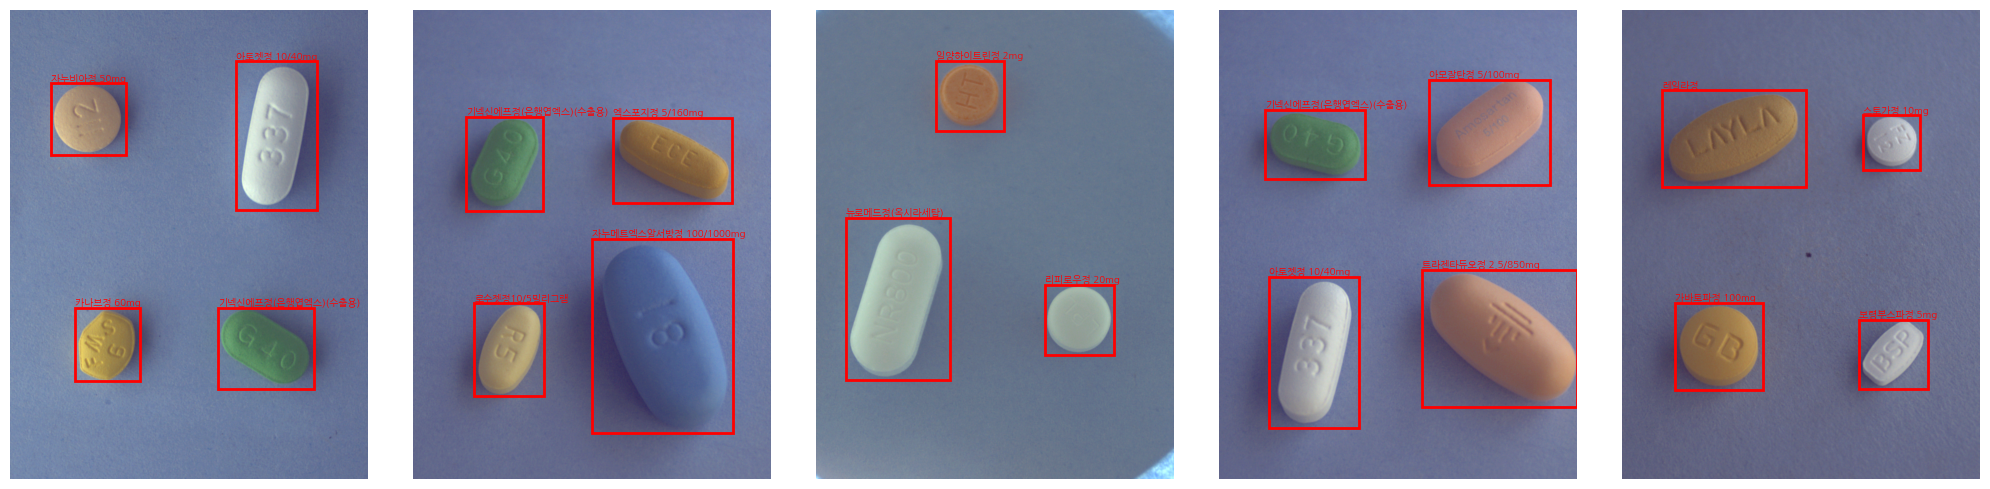

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

# bbox 컬럼 분리
df_ann[['bbox_x','bbox_y','bbox_w','bbox_h']] = pd.DataFrame(
    df_ann['bbox'].tolist(), index=df_ann.index
)

# 샘플 이미지 5장 시각화
sample_images = df_images.sample(5, random_state=42)

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for ax, (_, img_row) in zip(axes, sample_images.iterrows()):
    # 이미지 로드
    img_path = os.path.join(TRAIN_IMG_DIR, img_row['file_name'])
    img = Image.open(img_path)
    ax.imshow(img)

    # 해당 이미지의 bbox 그리기
    anns = df_ann[df_ann['image_id'] == img_row['id']]
    for _, ann in anns.iterrows():
        rect = patches.Rectangle(
            (ann['bbox_x'], ann['bbox_y']),
            ann['bbox_w'], ann['bbox_h'],
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        # 클래스 이름 표시
        cat = df_cat[df_cat['id'] == ann['category_id']]['name'].values
        if len(cat) > 0:
            ax.text(ann['bbox_x'], ann['bbox_y']-5,
                   cat[0], color='red', fontsize=7)

    ax.axis('off')

plt.tight_layout()
plt.show()

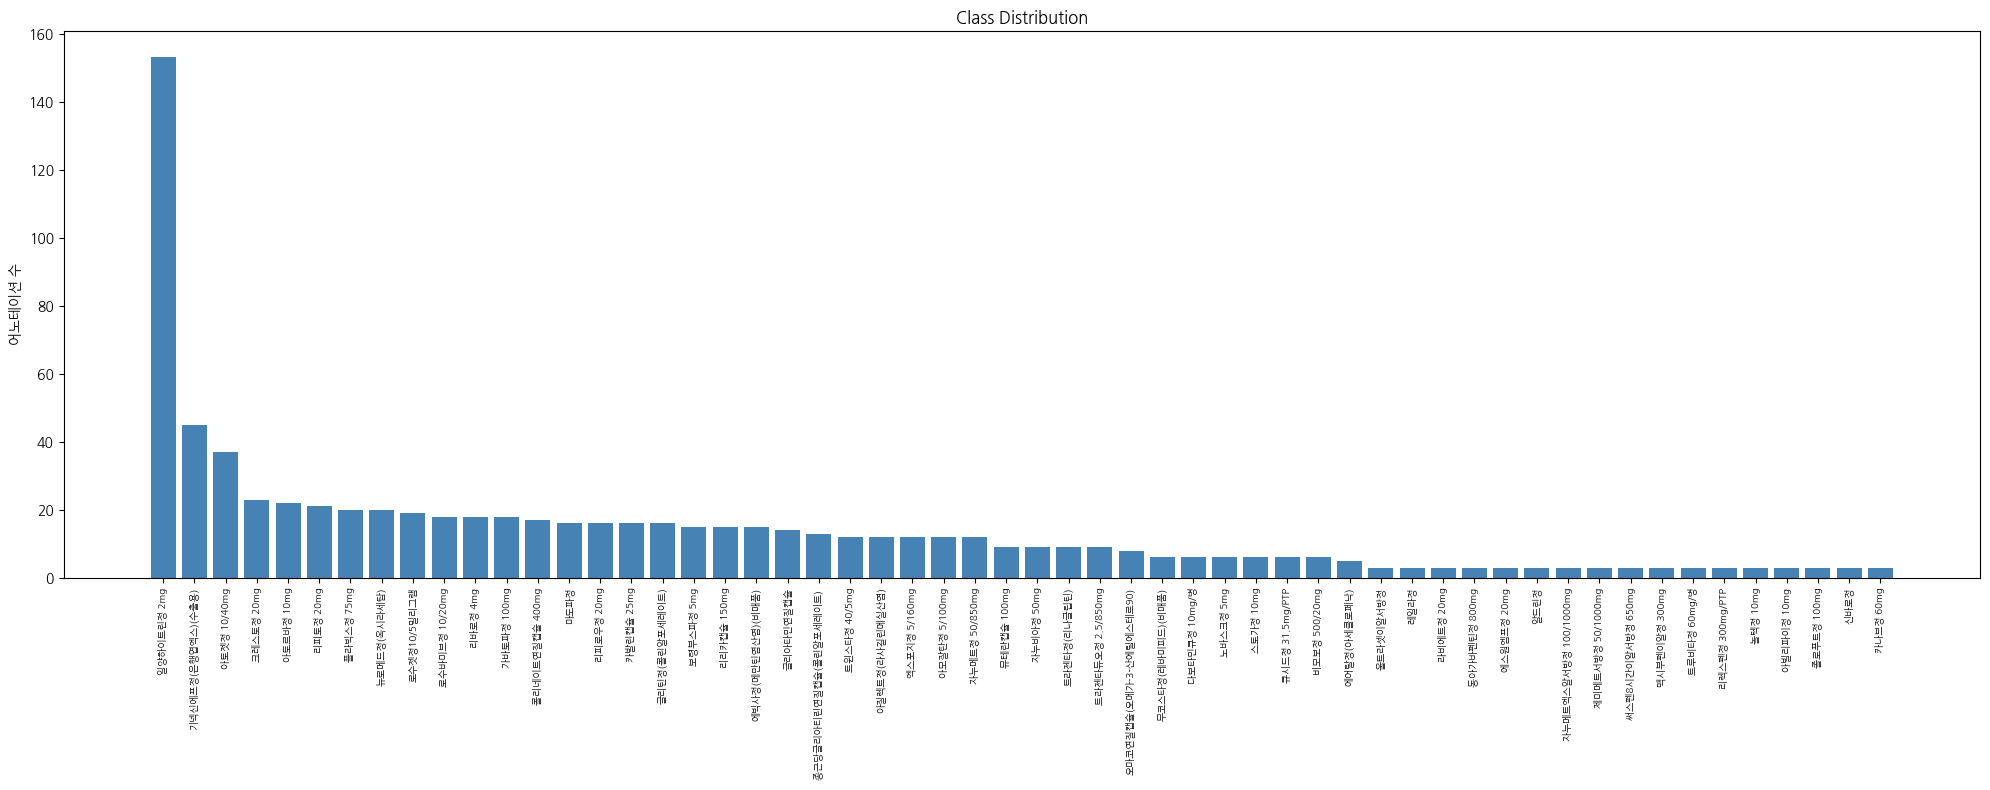


최다 클래스: 일양하이트린정 2mg (153개)
최소 클래스: 카나브정 60mg (3개)
불균형 비율: 51.0배


In [ ]:
# 카테고리 이름 매핑
cat_name_map = dict(zip(df_cat['id'], df_cat['name']))

# 클래스별 어노테이션 수 카운트
class_counts = df_ann['category_id'].value_counts()
class_names = [cat_name_map.get(i, str(i)) for i in class_counts.index]

plt.figure(figsize=(20, 8))
plt.bar(range(len(class_counts)), class_counts.values, color='steelblue')
plt.xticks(range(len(class_counts)), class_names, rotation=90, fontsize=7)
plt.ylabel('어노테이션 수')
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

print(f"\n최다 클래스: {class_names[0]} ({class_counts.values[0]}개)")
print(f"최소 클래스: {class_names[-1]} ({class_counts.values[-1]}개)")
print(f"불균형 비율: {class_counts.values[0] / class_counts.values[-1]:.1f}배")

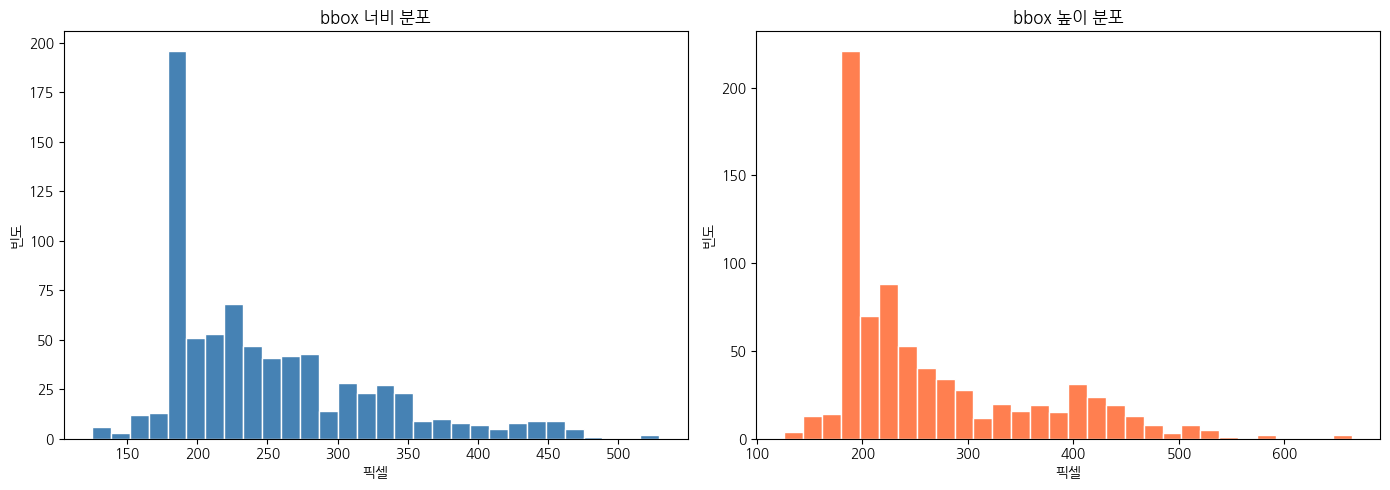

bbox 너비 — 평균: 250.0, 최소: 125, 최대: 529
bbox 높이 — 평균: 265.8, 최소: 126, 최대: 664


In [ ]:
bbox_w = df_ann['bbox_w']
bbox_h = df_ann['bbox_h']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(bbox_w, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('bbox 너비 분포')
axes[0].set_xlabel('픽셀')
axes[0].set_ylabel('빈도')

axes[1].hist(bbox_h, bins=30, color='coral', edgecolor='white')
axes[1].set_title('bbox 높이 분포')
axes[1].set_xlabel('픽셀')
axes[1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

print(f"bbox 너비 — 평균: {bbox_w.mean():.1f}, 최소: {bbox_w.min()}, 최대: {bbox_w.max()}")
print(f"bbox 높이 — 평균: {bbox_h.mean():.1f}, 최소: {bbox_h.min()}, 최대: {bbox_h.max()}")


### 인사이트

대부분 알약이 150~250px 사이에 몰려 있음

원본 이미지가 976×1280px인데 알약이 평균 250px이면 전체의 약 25% 크기

최대 664px짜리도 있어서 꽤 크기 편차가 있음

1024px로 업스케일하면 작은 알약 디테일이 더 잘 보여서 mAP 향상에 도움

In [ ]:
import os

YOLO_DIR = '/content/drive/MyDrive/pill_detection/yolo_data'
YOLO_LABEL_DIR = f'{YOLO_DIR}/labels/train'
YOLO_IMG_DIR   = f'{YOLO_DIR}/images/train'

os.makedirs(YOLO_LABEL_DIR, exist_ok=True)
os.makedirs(YOLO_IMG_DIR, exist_ok=True)

# category_id → 0부터 시작하는 인덱스로 매핑
cat_ids = sorted(df_cat['id'].unique())
cat_id_to_idx = {cat_id: idx for idx, cat_id in enumerate(cat_ids)}

# 이미지별로 YOLO txt 파일 생성
for _, img_row in df_images.iterrows():
    img_w = img_row['width']   # 976
    img_h = img_row['height']  # 1280
    img_id = img_row['id']
    file_stem = os.path.splitext(img_row['file_name'])[0]

    anns = df_ann[df_ann['image_id'] == img_id]

    lines = []
    for _, ann in anns.iterrows():
        x, y, w, h = ann['bbox_x'], ann['bbox_y'], ann['bbox_w'], ann['bbox_h']

        # COCO → YOLO 변환 (정규화)
        cx = (x + w / 2) / img_w
        cy = (y + h / 2) / img_h
        nw = w / img_w
        nh = h / img_h

        cls_idx = cat_id_to_idx[ann['category_id']]
        lines.append(f"{cls_idx} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

    # txt 저장
    with open(f'{YOLO_LABEL_DIR}/{file_stem}.txt', 'w') as f:
        f.write('\n'.join(lines))

print(f"YOLO 라벨 생성 완료: {len(os.listdir(YOLO_LABEL_DIR))}개")

YOLO 라벨 생성 완료: 232개


In [ ]:
import shutil

for _, img_row in df_images.iterrows():
    src = os.path.join(TRAIN_IMG_DIR, img_row['file_name'])
    dst = os.path.join(YOLO_IMG_DIR, img_row['file_name'])
    shutil.copy2(src, dst)

print(f"이미지 복사 완료: {len(os.listdir(YOLO_IMG_DIR))}개")

이미지 복사 완료: 232개


In [ ]:
import yaml

# 클래스 이름 리스트 (인덱스 순서대로)
class_names = [cat_name_map[cat_id] for cat_id in cat_ids]

data_yaml = {
    'path': YOLO_DIR,
    'train': 'images/train',
    'val': 'images/train',  # 데이터 적어서 train=val로 설정
    'nc': len(class_names),
    'names': class_names
}

yaml_path = f'{YOLO_DIR}/data.yaml'
with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(data_yaml, f, allow_unicode=True, default_flow_style=False)

print(f"data.yaml 생성 완료!")
print(f"클래스 수: {len(class_names)}")
print(f"첫 3개 클래스: {class_names[:3]}")

data.yaml 생성 완료!
클래스 수: 56
첫 3개 클래스: ['보령부스파정 5mg', '뮤테란캡슐 100mg', '일양하이트린정 2mg']


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=1024,
    batch=8,
    project=f'{BASE}/runs',
    name='baseline_yolov8s',
    exist_ok=True,
    patience=20,
    save=True,
    device=0
)

print("학습 완료!")
print(f"best.pt 저장 위치: {BASE}/runs/baseline_yolov8s/weights/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/pill_detection/yolo_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, 

In [ ]:
import pandas as pd

# 베스트 모델 로드
best_model = YOLO(f'{BASE}/runs/baseline_yolov8s/weights/best.pt')

# test 이미지 경로 목록
test_images = sorted([
    os.path.join(TEST_IMG_DIR, f)
    for f in os.listdir(TEST_IMG_DIR)
    if f.endswith('.png')
])

print(f"test 이미지 수: {len(test_images)}")

# inference
results_list = []
annotation_id = 1

for img_path in test_images:
    # image_id = 파일명에서 숫자 추출
    file_name = os.path.basename(img_path)
    image_id = int(os.path.splitext(file_name)[0].split('_')[-1])

    result = best_model(img_path, imgsz=1024, conf=0.25, verbose=False)[0]

    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        continue

    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        bbox_x = x1
        bbox_y = y1
        bbox_w = x2 - x1
        bbox_h = y2 - y1
        score = float(box.conf[0])
        cls_idx = int(box.cls[0])
        category_id = cat_ids[cls_idx]

        results_list.append({
            'annotation_id': annotation_id,
            'image_id': image_id,
            'category_id': category_id,
            'bbox_x': round(bbox_x, 2),
            'bbox_y': round(bbox_y, 2),
            'bbox_w': round(bbox_w, 2),
            'bbox_h': round(bbox_h, 2),
            'score': round(score, 4)
        })
        annotation_id += 1

df_submission = pd.DataFrame(results_list)
csv_path = f'{OUTPUT_DIR}/submission_baseline.csv'
df_submission.to_csv(csv_path, index=False)

print(f"제출 파일 생성 완료!")
print(f"총 예측 수: {len(df_submission)}")
print(df_submission.head())

test 이미지 수: 842
제출 파일 생성 완료!
총 예측 수: 3263
   annotation_id  image_id  category_id  bbox_x  bbox_y  bbox_w  bbox_h  \
0              1         1        27926  599.26  676.33  254.82  476.51   
1              2         1         1900  158.27  253.04  201.98  122.96   
2              3         1        29345  172.30  743.82  179.44  295.92   
3              4         1        16551  558.11   73.76  397.01  403.34   
4              5         1        27733  556.25   74.85  398.00  401.48   

    score  
0  0.9996  
1  0.9953  
2  0.9765  
3  0.9223  
4  0.5438  


In [ ]:
from google.colab import files
files.download(csv_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model_m = YOLO('yolov8m.pt')

results_m = model_m.train(
    data=yaml_path,
    epochs=50,
    imgsz=1024,
    batch=8,
    project=f'{BASE}/runs',
    name='yolov8m_exp',
    exist_ok=True,
    patience=20,
    save=True,
    device=0
)
print("YOLOv8m 학습 완료!")

Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/pill_detection/yolo_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_exp, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

In [ ]:
best_model_m = YOLO(f'{BASE}/runs/yolov8m_exp/weights/best.pt')

results_list = []
annotation_id = 1

for img_path in test_images:
    file_name = os.path.basename(img_path)
    image_id = int(os.path.splitext(file_name)[0].split('_')[-1])

    result = best_model_m(img_path, imgsz=1024, conf=0.25, verbose=False)[0]

    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        continue

    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        score = float(box.conf[0])
        cls_idx = int(box.cls[0])
        category_id = cat_ids[cls_idx]

        results_list.append({
            'annotation_id': annotation_id,
            'image_id': image_id,
            'category_id': category_id,
            'bbox_x': round(x1, 2),
            'bbox_y': round(y1, 2),
            'bbox_w': round(x2 - x1, 2),
            'bbox_h': round(y2 - y1, 2),
            'score': round(score, 4)
        })
        annotation_id += 1

df_sub_m = pd.DataFrame(results_list)
csv_path_m = f'{OUTPUT_DIR}/submission_yolov8m.csv'
df_sub_m.to_csv(csv_path_m, index=False)

print(f"완료! 총 예측 수: {len(df_sub_m)}")

완료! 총 예측 수: 3259


In [ ]:
model_11s = YOLO('yolo11s.pt')

results_11s = model_11s.train(
    data=yaml_path,
    epochs=50,
    imgsz=1024,
    batch=8,
    project=f'{BASE}/runs',
    name='yolo11s_exp',
    exist_ok=True,
    patience=20,
    save=True,
    device=0
)
print("YOLOv11s 학습 완료!")

Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/pill_detection/yolo_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_exp, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

In [ ]:
import gc
import torch

# 메모리 정리
del model, model_m, model_11s
gc.collect()
torch.cuda.empty_cache()

print("메모리 정리 완료!")

메모리 정리 완료!


In [ ]:
from ultralytics import YOLO

model_aug = YOLO('yolo11s.pt')

results_aug = model_aug.train(
    data=yaml_path,
    epochs=50,
    imgsz=1024,
    batch=8,
    project=f'{BASE}/runs',
    name='yolo11s_augmented',
    exist_ok=True,
    patience=20,
    save=True,
    device=0,
    # 증강 파라미터 추가
    degrees=30.0,       # 회전 증강 (각도 대응)
    hsv_h=0.015,        # 색상 변환
    hsv_s=0.7,          # 채도 변환 (조명 대응)
    hsv_v=0.4,          # 밝기 변환
    fliplr=0.5,         # 좌우 반전
    flipud=0.3,         # 상하 반전
    mosaic=1.0,         # 모자이크 증강
    erasing=0.4,        # CoarseDropout 대응
    scale=0.5,          # 크기 변환
    translate=0.1,      # 이동 변환
)

print("증강 적용 YOLOv11s 학습 완료!")

Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/pill_detection/yolo_data/data.yaml, degrees=30.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_augmented, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

In [ ]:
models_to_infer = {
    'yolov8m': f'{BASE}/runs/yolov8m_exp/weights/best.pt',
    'yolo11s': f'{BASE}/runs/yolo11s_exp/weights/best.pt',
    'yolo11s_aug': f'{BASE}/runs/yolo11s_augmented/weights/best.pt',
}

for model_name, model_path in models_to_infer.items():
    print(f"\n{model_name} inference 시작...")
    infer_model = YOLO(model_path)

    results_list = []
    annotation_id = 1

    for img_path in test_images:
        file_name = os.path.basename(img_path)
        image_id = int(os.path.splitext(file_name)[0].split('_')[-1])

        result = infer_model(img_path, imgsz=1024, conf=0.25, verbose=False)[0]
        boxes = result.boxes
        if boxes is None or len(boxes) == 0:
            continue

        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            score = float(box.conf[0])
            cls_idx = int(box.cls[0])
            category_id = cat_ids[cls_idx]

            results_list.append({
                'annotation_id': annotation_id,
                'image_id': image_id,
                'category_id': category_id,
                'bbox_x': round(x1, 2),
                'bbox_y': round(y1, 2),
                'bbox_w': round(x2 - x1, 2),
                'bbox_h': round(y2 - y1, 2),
                'score': round(score, 4)
            })
            annotation_id += 1

    df_sub = pd.DataFrame(results_list)
    csv_path_out = f'{OUTPUT_DIR}/submission_{model_name}.csv'
    df_sub.to_csv(csv_path_out, index=False)
    print(f"{model_name} 완료! 예측 수: {len(df_sub)}")


yolov8m inference 시작...
yolov8m 완료! 예측 수: 3259

yolo11s inference 시작...
yolo11s 완료! 예측 수: 3221

yolo11s_aug inference 시작...
yolo11s_aug 완료! 예측 수: 3236
